# Пілот: AI-видимість українських банків у відповідях LLM




Пілотний зріз для статті «Видимість українських брендів у відповідях генеративних пошукових систем». Дизайн — у `sample-design.md`, логіка — в `audit.py`, тести — `test_audit.py`.

**Що робить ноутбук**

1. Формує завдання: 20 небрендованих запитів × конфігурації моделей × повтори. Перед кожним запитом стоїть «Я живу в Україні.»
2. Оцінює вартість **до** будь-яких викликів.
3. Збирає відповіді через OpenRouter у `data/pilot_responses.jsonl`. Збір можна переривати й продовжувати.
4. Рахує згадуваність, позицію, share of voice, стабільність між повторами, джерела цитування.
5. Оцінює тональність через LLM-суддю і фіксує бренди поза нашим списком.
6. Перевіряє вплив геоприв'язки на 5 запитах.

Клітинки, що витрачають гроші, вимкнені прапорцями `RUN_*`. Вмикай їх свідомо.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import find_dotenv, load_dotenv

import audit

load_dotenv(find_dotenv(usecwd=True))

RESPONSES_PATH = Path("data/pilot_responses.jsonl")
JUDGEMENTS_PATH = Path("data/pilot_judgements.jsonl")

REPEATS = 5
GEO_CHECK_QUERIES = 5

MODEL_CONFIGS = [
    {"model": "openai/gpt-5.6-sol", "web_search": False},
    {"model": "anthropic/claude-sonnet-5", "web_search": False},
    {"model": "google/gemini-3.8-flash", "web_search": False},
    {"model": "deepseek/deepseek-v4-pro-0813", "web_search": False},
    {"model": "perplexity/sonar-pro", "web_search": True, "native_search": True},
]
JUDGE_MODEL = "openai/gpt-5.6-luna"

RUN_SMOKE = False
RUN_PILOT = True
RUN_JUDGE = True

## 1. Завдання та оцінка вартості

Оцінка груба й навмисно завищена. Фактичну вартість кожного виклику OpenRouter повертає у відповіді, вона зберігається в `usage.cost`.

In [2]:
queries = audit.build_queries("bank", audit.BANK_QUERIES)

main_tasks = audit.build_tasks(MODEL_CONFIGS, queries, REPEATS, lang="uk", geo=True)
geo_check_tasks = audit.build_tasks(MODEL_CONFIGS, queries[:GEO_CHECK_QUERIES], REPEATS, lang="uk", geo=False)
tasks = main_tasks + geo_check_tasks

prices = audit.fetch_catalog_prices()
missing = sorted(({t["model"] for t in tasks} | {JUDGE_MODEL}) - set(prices))
assert not missing, f"Немає в каталозі OpenRouter: {missing}"

estimate = audit.estimate_cost(tasks, prices)
print(f"Викликів: {len(tasks)} (основних {len(main_tasks)}, перевірка геоприв'язки {len(geo_check_tasks)})")
print(f"Оцінка збору: ${estimate['cost_usd'].sum():.2f}")
estimate

Викликів: 750 (основних 600, перевірка геоприв'язки 150)
Оцінка збору: $19.51


calls  cost_usd
model                         web_search                 
anthropic/claude-sonnet-5     False         125      1.27
deepseek/deepseek-v4-pro-0813 False         125      0.22
google/gemini-3.8-flash       False         125      0.47
openai/gpt-5.6-sol            False         125      1.27
                              True          125     13.76
perplexity/sonar-pro          True          125      2.52

## 2. Димовий тест

Один запит на кожну конфігурацію моделі. Перевіряє формат відповіді, наявність цитувань у моделей з пошуком і поле вартості. Результати в основний файл не пишуться.

In [3]:
if RUN_SMOKE:
    smoke_tasks = audit.build_tasks(MODEL_CONFIGS, queries[:1], repeats=1)
    with audit.make_client() as client:
        for task in smoke_tasks:
            record = audit.call_model(client, task)
            print(f"===== {audit.model_label(record)} | served: {record['served_model']} | "
                  f"finish: {record['finish_reason']} | cost: {(record['usage'] or {}).get('cost')}")
            print("Бренди:", [m["brand"] for m in audit.find_mentions(record["response_text"], audit.BANK_BRANDS)])
            print("Цитувань:", len(record["citations"]), record["citations"][:3])
            print(record["response_text"][:400], "\n")

## 3. Збір відповідей

In [4]:
if RUN_PILOT:
    moved = audit.set_aside_truncated(RESPONSES_PATH, JUDGEMENTS_PATH)
    print(f"Обрізаних відповідей відкладено для повторного збору: {moved}")
    failed = audit.run_collection(tasks, RESPONSES_PATH, workers=6)
    for task, error in failed[:10]:
        print(audit.task_key(task), error)

Зібрано раніше: 0, до виконання: 750
  25/750 (помилок: 0)
  50/750 (помилок: 0)
  75/750 (помилок: 0)
  100/750 (помилок: 0)
  125/750 (помилок: 0)
  150/750 (помилок: 0)
  175/750 (помилок: 0)
  200/750 (помилок: 0)
  225/750 (помилок: 0)
  250/750 (помилок: 0)
  275/750 (помилок: 0)
  300/750 (помилок: 0)
  325/750 (помилок: 0)
  350/750 (помилок: 0)
  375/750 (помилок: 0)
  400/750 (помилок: 0)
  425/750 (помилок: 0)
  450/750 (помилок: 0)
  475/750 (помилок: 0)
  500/750 (помилок: 0)
  525/750 (помилок: 0)
  550/750 (помилок: 0)
  575/750 (помилок: 0)
  600/750 (помилок: 0)
  625/750 (помилок: 0)
  650/750 (помилок: 0)
  675/750 (помилок: 0)
  700/750 (помилок: 0)
  725/750 (помилок: 0)
  750/750 (помилок: 0)


## 4. Дані


In [5]:
collected = audit.load_jsonl(RESPONSES_PATH)
records = audit.filter_to_configs(collected, MODEL_CONFIGS)
print(f"У файлі {len(collected)} відповідей, в аналізі {len(records)} (лише конфігурації з MODEL_CONFIGS)")
responses_all = audit.responses_frame(records)
mentions_all = audit.mentions_frame(records, audit.BANK_BRANDS)

responses = responses_all[responses_all["geo"]]
mentions = mentions_all[mentions_all["geo"]]

print(f"Відповідей: {len(responses_all)}, фактична вартість: ${responses_all['cost_usd'].sum():.2f}")
print(f"Зріз: {responses_all['timestamp'].min()} — {responses_all['timestamp'].max()}")
print("Мова відповідей на україномовні запити:")
print(pd.crosstab(responses_all["model_label"], responses_all["response_lang"]))
print(f"Обрізаних за max_tokens: {responses_all['truncated'].sum()}, порожніх: {(responses_all['response_text'] == '').sum()}")
responses_all.groupby("model_label").agg(responses=("repeat", "size"), cost_usd=("cost_usd", "sum"), served=("served_model", "unique"))

Відповідей: 750, фактична вартість: $20.47
Зріз: 2026-09-18T15:39:00.628223+00:00 — 2026-09-18T16:38:06.240356+00:00
Мова відповідей на україномовні запити:
response_lang         ru   uk  unknown
model_label                           
claude-sonnet-5        0  125        0
deepseek-v4-pro-0813   3  105       17
gemini-3.8-flash       0  125        0
gpt-5.6-sol            0  125        0
gpt-5.6-sol +web       0  125        0
sonar-pro +web         0  125        0
Обрізаних за max_tokens: 22, порожніх: 17


,responses,cost_usd,served
model_label,,,
claude-sonnet-5,125,0.835650,[anthropic/claude-sonnet-5]
deepseek-v4-pro-0813,125,0.817916,[deepseek/deepseek-v4-pro-0813]
gemini-3.8-flash,125,1.063877,[google/gemini-3.8-flash]
gpt-5.6-sol,125,0.923590,[openai/gpt-5.6-sol]
gpt-5.6-sol +web,125,15.045932,[openai/gpt-5.6-sol]
sonar-pro +web,125,1.780630,[perplexity/sonar-pro]


## 5. Згадуваність і позиція


- `mention_rate` — частка відповідей моделі, де бренд згадано.
- `mean_rank` — середній порядковий номер першої згадки серед відстежуваних брендів.
- `first_place_rate` — частка відповідей, де бренд згадано першим.

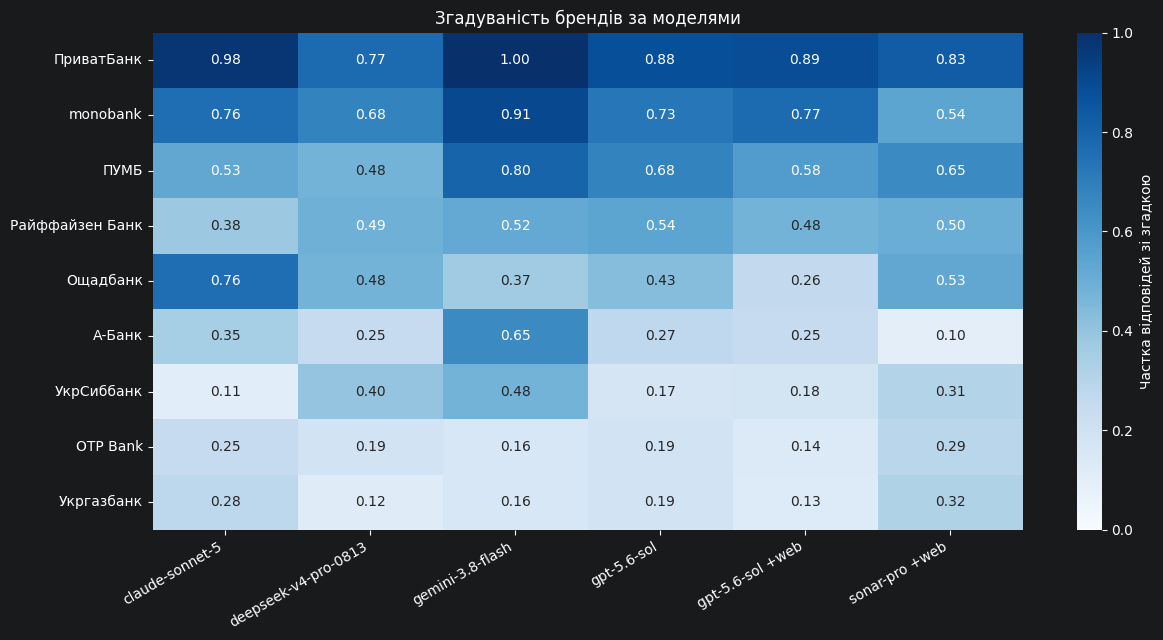

,model_label,brand,mentions,mean_rank,responses,mention_rate,first_place_rate
5,claude-sonnet-5,ПриватБанк,98,1.73,100,0.98,0.42
1,claude-sonnet-5,monobank,76,1.66,100,0.76,0.47
3,claude-sonnet-5,Ощадбанк,76,2.89,100,0.76,0.10
4,claude-sonnet-5,ПУМБ,53,3.40,100,0.53,0.00
6,claude-sonnet-5,Райффайзен Банк,38,4.39,100,0.38,0.00
2,claude-sonnet-5,А-Банк,35,4.83,100,0.35,0.00
8,claude-sonnet-5,Укргазбанк,28,2.89,100,0.28,0.01
0,claude-sonnet-5,OTP Bank,25,4.72,100,0.25,0.00
7,claude-sonnet-5,УкрСиббанк,11,4.45,100,0.11,0.00
14,deepseek-v4-pro-0813,ПриватБанк,77,1.81,100,0.77,0.22


In [6]:
visibility = audit.visibility_table(responses, mentions)
rate_matrix = visibility.pivot(index="brand", columns="model_label", values="mention_rate").fillna(0)
rate_matrix = rate_matrix.loc[rate_matrix.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(1.6 * rate_matrix.shape[1] + 3, 0.5 * rate_matrix.shape[0] + 2))
sns.heatmap(rate_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Частка відповідей зі згадкою"})
ax.set(title="Згадуваність брендів за моделями", xlabel="", ylabel="")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

visibility.sort_values(["model_label", "mention_rate"], ascending=[True, False])

In [7]:
sov = audit.share_of_voice(mentions)
sov.pivot(index="brand", columns="model_label", values="share_of_voice").fillna(0).round(3)

model_label,claude-sonnet-5,deepseek-v4-pro-0813,gemini-3.8-flash,gpt-5.6-sol,gpt-5.6-sol +web,sonar-pro +web
brand,,,,,,
OTP Bank,0.057,0.049,0.032,0.047,0.038,0.071
monobank,0.173,0.176,0.180,0.179,0.209,0.133
А-Банк,0.080,0.065,0.129,0.066,0.068,0.025
Ощадбанк,0.173,0.124,0.073,0.105,0.071,0.130
ПУМБ,0.120,0.124,0.158,0.167,0.158,0.160
ПриватБанк,0.223,0.199,0.198,0.216,0.242,0.204
Райффайзен Банк,0.086,0.127,0.103,0.132,0.130,0.123
УкрСиббанк,0.025,0.104,0.095,0.042,0.049,0.076
Укргазбанк,0.064,0.031,0.032,0.047,0.035,0.079


In [8]:
by_intent = audit.visibility_table(responses, mentions, by="intent")
by_intent.pivot(index="brand", columns="intent", values="mention_rate").fillna(0)

intent,BEST,COMP,PRICE,TASK,TRUST
brand,,,,,
OTP Bank,0.200,0.158,0.008,0.150,0.500
monobank,0.767,0.817,0.750,0.683,0.642
А-Банк,0.333,0.392,0.383,0.317,0.133
Ощадбанк,0.567,0.342,0.300,0.525,0.625
ПУМБ,0.650,0.750,0.625,0.683,0.392
ПриватБанк,0.958,0.900,0.700,0.958,0.942
Райффайзен Банк,0.558,0.350,0.192,0.558,0.767
УкрСиббанк,0.392,0.142,0.133,0.200,0.508
Укргазбанк,0.117,0.200,0.050,0.283,0.350


## 6. Стабільність між повторами

Коефіцієнт Жаккара між наборами брендів у повторах того самого запиту тією самою моделлю: 1 — набір щоразу однаковий, 0 — жодного перетину. Від цього залежить, чи вистачить 5 повторів у повному зрізі, чи потрібно 8.

                      count   mean    std    min    25%    50%    75%  max
model_label                                                               
claude-sonnet-5        20.0  0.704  0.136  0.534  0.602  0.685  0.800  1.0
deepseek-v4-pro-0813   20.0  0.555  0.197  0.286  0.397  0.533  0.663  1.0
gemini-3.8-flash       20.0  0.884  0.096  0.617  0.828  0.877  0.967  1.0
gpt-5.6-sol            20.0  0.818  0.128  0.595  0.738  0.820  0.908  1.0
gpt-5.6-sol +web       20.0  0.748  0.162  0.342  0.691  0.790  0.854  1.0
sonar-pro +web         20.0  0.780  0.186  0.267  0.752  0.792  0.904  1.0


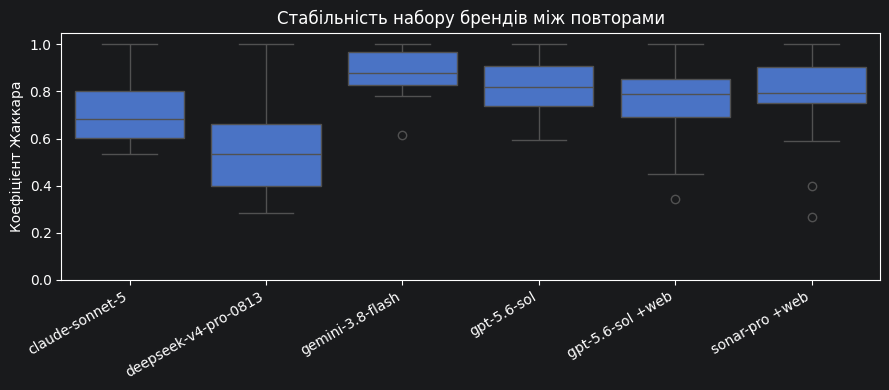

In [9]:
stability = audit.repeat_stability(responses, mentions)
print(stability.groupby("model_label")["jaccard"].describe().round(3))

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=stability, x="model_label", y="jaccard", ax=ax)
ax.set(title="Стабільність набору брендів між повторами", xlabel="", ylabel="Коефіцієнт Жаккара", ylim=(0, 1.05))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Джерела цитування (моделі з веб-пошуком)

In [10]:
citations = audit.citations_frame([r for r in records if r["geo"]], audit.BANK_BRAND_DOMAINS)
if citations.empty:
    print("Цитувань немає — перевір димовий тест для моделей з веб-пошуком.")
else:
    print(pd.crosstab(citations["domain_type"], citations["model_label"], normalize="columns").round(3))
    print("\nТоп-20 доменів:")
    print(citations["domain"].value_counts().head(20))
    print("\nДомен 'other' варто переглянути вручну й доповнити audit.DOMAIN_TYPES:")
    print(citations.loc[citations["domain_type"] == "other", "domain"].value_counts().head(20))

model_label    gpt-5.6-sol +web  sonar-pro +web
domain_type                                    
brand_site                0.610           0.089
fin_portal                0.036           0.208
media                     0.000           0.087
other                     0.118           0.589
regulator_gov             0.236           0.021
wikipedia                 0.000           0.004

Топ-20 доменів:
domain
minfin.com.ua      322
privatbank.ua      138
finance.ua         106
rbc.ua             106
monobank.ua        105
bank.gov.ua         79
focus.ua            75
raiffeisen.ua       68
my.ua               60
psm7.com            55
obozrevatel.com     51
delo.ua             45
banker.ua           45
pumb.ua             41
24tv.ua             36
financer.com.ua     35
forinsurer.com      30
financy.24tv.ua     30
news.finance.ua     29
thepage.ua          29
Name: count, dtype: int64

Домен 'other' варто переглянути вручну й доповнити audit.DOMAIN_TYPES:
domain
rbc.ua                   10

## 8. Тональність і бренди поза списком (LLM-суддя)

Суддя отримує лише текст відповіді, без запиту й назви моделі. Два контролі якості:

- узгодженість із регулярними виразами — чи бачить суддя ті самі відстежувані бренди;
- бренди поза списком — кого ми пропустили у вибірці.

In [11]:
if RUN_JUDGE:
    failed = audit.run_judging(records, JUDGEMENTS_PATH, JUDGE_MODEL)
    print(failed[:10])

Оцінено раніше: 0, до виконання: 733
  50/733 (помилок: 0)
  100/733 (помилок: 0)
  150/733 (помилок: 0)
  200/733 (помилок: 0)
  250/733 (помилок: 1)
  300/733 (помилок: 4)
  350/733 (помилок: 4)
  400/733 (помилок: 7)
  450/733 (помилок: 7)
  500/733 (помилок: 7)
  550/733 (помилок: 7)
  600/733 (помилок: 7)
  650/733 (помилок: 7)
  700/733 (помилок: 8)
  733/733 (помилок: 8)
[(('google/gemini-3.8-flash', False, 'bank-08', 'uk', True, 5), 'JSONDecodeError("Expecting \',\' delimiter: line 1 column 603 (char 602)")'), (('google/gemini-3.8-flash', False, 'bank-12', 'uk', True, 4), 'JSONDecodeError("Expecting \',\' delimiter: line 1 column 66 (char 65)")'), (('google/gemini-3.8-flash', False, 'bank-17', 'uk', True, 3), 'JSONDecodeError("Expecting \',\' delimiter: line 1 column 63 (char 62)")'), (('google/gemini-3.8-flash', False, 'bank-17', 'uk', True, 1), 'JSONDecodeError("Expecting \',\' delimiter: line 1 column 176 (char 175)")'), (('deepseek/deepseek-v4-pro-0813', False, 'bank-10', '

In [15]:
judgements = audit.load_jsonl(JUDGEMENTS_PATH)
sentiment = audit.sentiment_frame(records, judgements, audit.BANK_BRANDS)
sentiment = sentiment[sentiment["geo"]]

tracked = sentiment[sentiment["tracked"]]
summary = tracked.groupby("brand").agg(
    mentions=("sentiment", "size"),
    mean_sentiment=("sentiment", "mean"),
    recommended_rate=("recommended", "mean"),
).round(3).sort_values("mentions", ascending=False)
print(summary)

print("\nБренди поза списком:")
print(sentiment.loc[~sentiment["tracked"], "brand"].value_counts().head(25))

                 mentions  mean_sentiment  recommended_rate
brand                                                      
ПриватБанк            742           0.683             0.647
monobank              459           0.898             0.902
ПУМБ                  417           0.820             0.616
Райффайзен Банк       323           0.740             0.687
Ощадбанк              299           0.629             0.632
А-Банк                197           0.665             0.431
УкрСиббанк            175           0.749             0.703
OTP Bank              137           0.781             0.606
Укргазбанк            124           0.637             0.565

Бренди поза списком:
brand
Sense Bank             210
Укрексімбанк            97
Універсал Банк          83
Альфа-Банк              70
Креді Агріколь          63
Кредобанк               60
Sense SuperApp          56
Universal Bank          53
Сенс Банк               50
Finance.ua              49
Дія                     42
BNP Paribas    

In [16]:
cell = ["model_label", "query_id", "repeat"]
regex_pairs = set(map(tuple, mentions[cell + ["brand"]].drop_duplicates().to_numpy()))
judge_pairs = set(map(tuple, tracked[cell + ["brand"]].drop_duplicates().to_numpy()))
judged_cells = set(map(tuple, sentiment[cell].drop_duplicates().to_numpy()))
regex_pairs = {p for p in regex_pairs if p[:3] in judged_cells}

both = len(regex_pairs & judge_pairs)
print(f"Згадки, знайдені обома методами: {both}")
print(f"Лише регулярні вирази: {len(regex_pairs - judge_pairs)}; лише суддя: {len(judge_pairs - regex_pairs)}")
print(f"Узгодженість (Жаккар): {both / max(len(regex_pairs | judge_pairs), 1):.3f}")

Згадки, знайдені обома методами: 2480
Лише регулярні вирази: 10; лише суддя: 99
Узгодженість (Жаккар): 0.958


## 9. Перевірка геоприв'язки

Ті самі 5 запитів із реченням «Я живу в Україні.» і без нього. Якщо без геоприв'язки частка відповідей з українськими брендами різко падає, рішення ставити її в усі запити підтверджено.

In [17]:
geo_ids = [q["query_id"] for q in queries[:GEO_CHECK_QUERIES]]
subset = responses_all[responses_all["query_id"].isin(geo_ids)]
keys = ["model_label", "query_id", "repeat", "geo"]
brands_per_response = mentions_all.groupby(keys).size().rename("tracked_brands").reset_index()
geo_cmp = subset.merge(brands_per_response, on=keys, how="left").fillna({"tracked_brands": 0})

geo_cmp.groupby(["model_label", "geo"]).agg(
    responses=("repeat", "size"),
    any_tracked_brand=("tracked_brands", lambda s: (s > 0).mean().round(3)),
    mean_tracked_brands=("tracked_brands", "mean"),
).round(2)

responses  any_tracked_brand  mean_tracked_brands
model_label          geo                                                     
claude-sonnet-5      False         25               0.92                 4.32
                     True          25               1.00                 4.92
deepseek-v4-pro-0813 False         25               1.00                 4.92
                     True          25               0.96                 5.44
gemini-3.8-flash     False         25               1.00                 4.96
                     True          25               1.00                 5.08
gpt-5.6-sol          False         25               0.96                 4.44
                     True          25               1.00                 4.72
gpt-5.6-sol +web     False         25               0.64                 2.56
                     True          25               1.00                 3.96
sonar-pro +web       False         25               1.00                 4.16
                     True          25               0.80                 3.84